# Notebook 5: End-to-End Evaluation
**Skin Lesion Risk Advisor**

Dieses Notebook evaluiert die **vollständige Pipeline**:
```
Bild → CV → risk_level (ML) → Erklärung (NLP)
```

Bewertet werden:
1. CV-Performance (final)
2. ML-Performance (final)
3. Kombinierte Pipeline-Performance
4. Fehleranalyse
5. Qualitative NLP-Beispiele

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import os
from dotenv import load_dotenv
from transformers import pipeline as hf_pipeline
import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')

FIGURES_DIR = Path('../reports/figures')
MODELS_DIR  = Path('../models')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
HF_MODEL_ID = os.getenv('HF_MODEL_ID', 'YOUR_HF_USERNAME/vit-base-ham10000')

print(f'HF Model: {HF_MODEL_ID}')
print('Setup OK')


HF Model: PREMAADC/vit-base-ham10000
Setup OK


## 1. Modelle laden

In [2]:
# ML Modell
ml_model = joblib.load(MODELS_DIR / 'ml_risk_classifier.pkl')
le_sex   = joblib.load(MODELS_DIR / 'le_sex.pkl')
le_loc   = joblib.load(MODELS_DIR / 'le_loc.pkl')
le_risk  = joblib.load(MODELS_DIR / 'le_risk.pkl')
print('ML Modell geladen.')

# CV Modell: ViT von HuggingFace Hub (trainiert in Notebook 03)
from transformers import AutoImageProcessor
print(f'Lade ViT Pipeline: {HF_MODEL_ID} ...')
try:
    vit_processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')
    vit_pipe = hf_pipeline('image-classification', model=HF_MODEL_ID, image_processor=vit_processor)
    print('ViT Modell geladen.')
except Exception as e:
    print(f'FEHLER beim Laden des ViT Modells: {e}')
    vit_pipe = None

print('Setup abgeschlossen.')

ML Modell geladen.
Lade ViT Pipeline: PREMAADC/vit-base-ham10000 ...


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT Modell geladen.
Setup abgeschlossen.


## 2. Testdaten laden

In [3]:
df = pd.read_csv('../data/processed/metadata_with_split.csv')
df_test = df[df['split'] == 'test'].copy()
df_test = df_test[df_test['image_path'].notna()]

risk_map = {
    'mel': 'high', 'bcc': 'high',
    'akiec': 'medium',
    'bkl': 'low', 'nv': 'low', 'vasc': 'low', 'df': 'low'
}
df_test['risk_true'] = df_test['dx'].map(risk_map)

print(f'Testset: {len(df_test)} Einträge')

Testset: 1992 Einträge


## 3. CV Vorhersagen auf Testset

In [4]:
from tqdm import tqdm

def predict_image(image_path):
    """ViT Pipeline Inferenz — gibt (label, confidence) zurueck."""
    img = Image.open(image_path).convert('RGB')
    results = vit_pipe(img)
    best = results[0]
    return best['label'], float(best['score'])

# Sample von 200 fuer schnellere Evaluation
sample = df_test.sample(min(200, len(df_test)), random_state=42)

cv_preds, cv_confs = [], []
for _, row in tqdm(sample.iterrows(), total=len(sample), desc='CV Inference'):
    try:
        pred, conf = predict_image(row['image_path'])
    except Exception:
        pred, conf = 'nv', 0.5
    cv_preds.append(pred)
    cv_confs.append(conf)

sample = sample.copy()
sample['cv_pred'] = cv_preds
sample['cv_conf'] = cv_confs
sample['cv_correct'] = sample['cv_pred'] == sample['dx']

print(f'CV Accuracy (Sample): {sample["cv_correct"].mean():.3f}')


CV Inference: 100%|██████████| 200/200 [00:39<00:00,  5.08it/s]

CV Accuracy (Sample): 0.735


In [5]:
print('=== CV Performance (ViT Fine-tuned) ===')
print(f'Balanced Accuracy: {balanced_accuracy_score(sample["dx"], sample["cv_pred"]):.3f}')
print(f'F1 Macro:          {f1_score(sample["dx"], sample["cv_pred"], average="macro", labels=CLASS_NAMES, zero_division=0):.3f}')
print()
print(classification_report(sample['dx'], sample['cv_pred'], labels=CLASS_NAMES, zero_division=0))


=== CV Performance (ViT Fine-tuned) ===
Balanced Accuracy: 0.549
F1 Macro:          0.590

              precision    recall  f1-score   support

       akiec       0.33      0.11      0.17         9
         bcc       0.82      0.75      0.78        12
         bkl       0.29      0.47      0.36        15
          df       1.00      0.50      0.67         4
         mel       0.64      0.29      0.40        31
          nv       0.81      0.93      0.86       124
        vasc       1.00      0.80      0.89         5

    accuracy                           0.73       200
   macro avg       0.70      0.55      0.59       200
weighted avg       0.73      0.73      0.72       200



## 4. ML Vorhersagen auf Testset

In [6]:
# Bekannte Lokalisierungen
known_locs = set(le_loc.classes_)
sample['loc_safe'] = sample['localization'].apply(
    lambda x: x if x in known_locs else le_loc.classes_[0]
)

# Encoding
sample['sex_enc'] = le_sex.transform(sample['sex'])
sample['loc_enc'] = le_loc.transform(sample['loc_safe'])

# Feature Engineering identisch zu 02_ml_training.ipynb Iteration 2
sample['age_group']             = np.where(sample['age'] < 30, 0, np.where(sample['age'] <= 60, 1, 2)).astype(int)
sample['is_face']               = sample['localization'].isin(['face']).astype(int)
sample['is_trunk']              = sample['localization'].isin(['back', 'abdomen', 'chest', 'trunk']).astype(int)
sample['is_extremity']          = sample['localization'].isin(['lower extremity', 'upper extremity', 'foot', 'hand']).astype(int)
sample['is_high_risk_location'] = sample['localization'].isin(['back', 'lower extremity']).astype(int)

FEATURES_V2 = ['age', 'sex_enc', 'loc_enc', 'age_group',
                'is_face', 'is_trunk', 'is_extremity', 'is_high_risk_location']

X_test_ml = sample[FEATURES_V2]
ml_preds_enc = ml_model.predict(X_test_ml)
sample['ml_pred_risk'] = le_risk.inverse_transform(ml_preds_enc)

print('=== ML Performance (XGBoost Iter 2, 8 Features) ===')
print(f'Balanced Accuracy: {balanced_accuracy_score(sample["risk_true"], sample["ml_pred_risk"]):.3f}')
print(f'F1 Macro:          {f1_score(sample["risk_true"], sample["ml_pred_risk"], average="macro"):.3f}')
print()
print(classification_report(sample['risk_true'], sample['ml_pred_risk']))


=== ML Performance (XGBoost Iter 2, 8 Features) ===
Balanced Accuracy: 0.681
F1 Macro:          0.528

              precision    recall  f1-score   support

        high       0.38      0.47      0.42        43
         low       0.89      0.69      0.78       148
      medium       0.25      0.89      0.39         9

    accuracy                           0.65       200
   macro avg       0.50      0.68      0.53       200
weighted avg       0.75      0.65      0.68       200



## 5. Kombinierte Pipeline

CV-Vorhersage + ML-Risikoklasse werden kombiniert: wenn beide übereinstimmen → höhere Konfidenz.

In [7]:
cv_risk_map = {
    'mel': 'high', 'bcc': 'high',
    'akiec': 'medium',
    'bkl': 'low', 'nv': 'low', 'vasc': 'low', 'df': 'low'
}
sample['cv_risk'] = sample['cv_pred'].map(cv_risk_map)

# Kombinationsregel:
# - Wenn CV und ML übereinstimmen → verwende dieses Risiko
# - Wenn unterschiedlich → nehme das höhere Risiko (konservativ)
risk_order = {'low': 0, 'medium': 1, 'high': 2}

def combine_risk(cv_r, ml_r):
    if cv_r == ml_r:
        return cv_r
    return max([cv_r, ml_r], key=lambda x: risk_order.get(x, 0))

sample['combined_risk'] = sample.apply(
    lambda r: combine_risk(r['cv_risk'], r['ml_pred_risk']), axis=1
)

print('=== Kombinierte Pipeline Performance ===')
print(f'Balanced Accuracy: {balanced_accuracy_score(sample["risk_true"], sample["combined_risk"]):.3f}')
print(f'F1 Macro:          {f1_score(sample["risk_true"], sample["combined_risk"], average="macro"):.3f}')
print()
print(classification_report(sample['risk_true'], sample['combined_risk']))

=== Kombinierte Pipeline Performance ===
Balanced Accuracy: 0.756
F1 Macro:          0.597

              precision    recall  f1-score   support

        high       0.47      0.70      0.56        43
         low       0.93      0.68      0.79       148
      medium       0.30      0.89      0.44         9

    accuracy                           0.69       200
   macro avg       0.56      0.76      0.60       200
weighted avg       0.80      0.69      0.72       200



## 6. Vergleich aller Blöcke

          Modell  Balanced Accuracy  F1 Macro
  ML (Metadaten)              0.681     0.528
CV (ViT) -> Risk              0.502     0.536
      Kombiniert              0.756     0.597


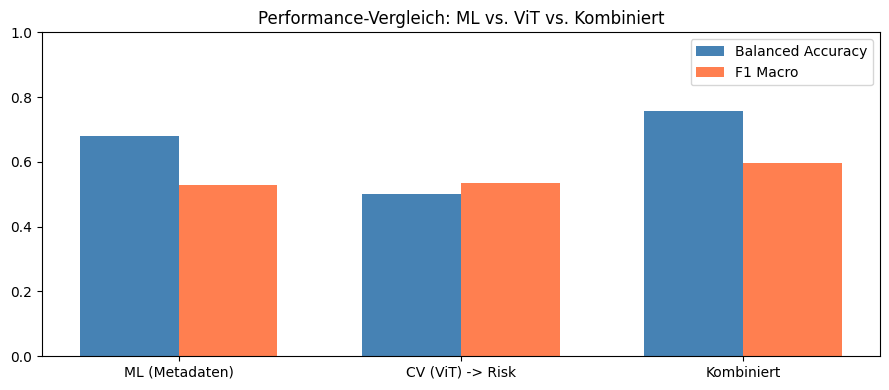

In [8]:
comparison = pd.DataFrame({
    'Modell': ['ML (Metadaten)', 'CV (ViT) -> Risk', 'Kombiniert'],
    'Balanced Accuracy': [
        balanced_accuracy_score(sample['risk_true'], sample['ml_pred_risk']),
        balanced_accuracy_score(sample['risk_true'], sample['cv_risk']),
        balanced_accuracy_score(sample['risk_true'], sample['combined_risk'])
    ],
    'F1 Macro': [
        f1_score(sample['risk_true'], sample['ml_pred_risk'], average='macro'),
        f1_score(sample['risk_true'], sample['cv_risk'], average='macro'),
        f1_score(sample['risk_true'], sample['combined_risk'], average='macro')
    ]
}).round(3)

print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison['Balanced Accuracy'], w, label='Balanced Accuracy', color='steelblue')
ax.bar(x + w/2, comparison['F1 Macro'], w, label='F1 Macro', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Modell'])
ax.set_ylim(0, 1)
ax.legend()
ax.set_title('Performance-Vergleich: ML vs. ViT vs. Kombiniert')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eval_01_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Fehleranalyse

In [9]:
errors = sample[sample['combined_risk'] != sample['risk_true']].copy()
print(f'Fehlerrate: {len(errors)/len(sample):.1%} ({len(errors)}/{len(sample)})')
print()

# Welche Fehler passieren häufig?
print('Häufigste Fehler (true → predicted):')
print(errors.groupby(['risk_true', 'combined_risk']).size().sort_values(ascending=False).head(10))

print()
print('Kritische Fehler (high als low klassifiziert):')
critical = errors[(errors['risk_true'] == 'high') & (errors['combined_risk'] == 'low')]
print(f'Anzahl: {len(critical)}')
if len(critical) > 0:
    print(critical[['dx', 'age', 'sex', 'localization', 'cv_pred', 'ml_pred_risk']].head())

Fehlerrate: 30.5% (61/200)

Häufigste Fehler (true → predicted):
risk_true  combined_risk
low        high             33
           medium           14
high       low               8
           medium            5
medium     high              1
dtype: int64

Kritische Fehler (high als low klassifiziert):
Anzahl: 8
       dx   age     sex     localization cv_pred ml_pred_risk
1989  mel  45.0  female  lower extremity      nv          low
2621  bcc  45.0    male          abdomen      nv          low
1352  mel  45.0  female  lower extremity      nv          low
1784  mel  40.0  female  lower extremity      nv          low
1850  mel  25.0  female  lower extremity     bkl          low


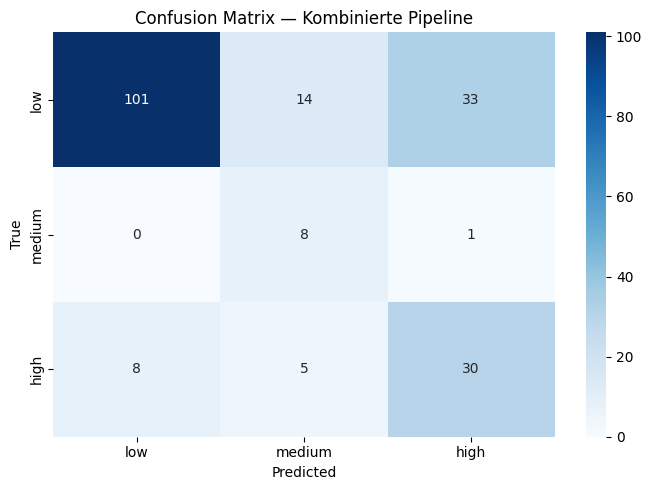

In [10]:
# Konfusion-Matrix der kombinierten Pipeline
risk_labels = ['low', 'medium', 'high']
cm = confusion_matrix(sample['risk_true'], sample['combined_risk'], labels=risk_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=risk_labels, yticklabels=risk_labels)
plt.title('Confusion Matrix — Kombinierte Pipeline')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eval_02_combined_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Qualitative NLP-Beispiele


Wahrer Befund: mel | Risiko: high
CV Vorhersage: nv (69% Konfidenz)
ML Risiko:     medium
Kombiniert:    medium
Patient:       60 J., female, lower extremity


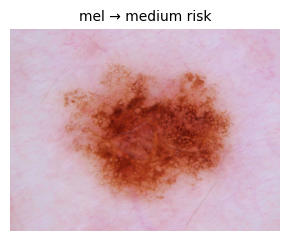


Wahrer Befund: nv | Risiko: low
CV Vorhersage: nv (96% Konfidenz)
ML Risiko:     low
Kombiniert:    low
Patient:       45 J., male, lower extremity


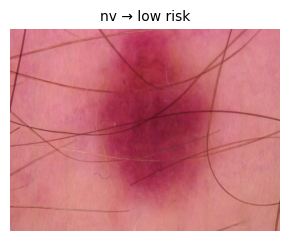


Wahrer Befund: akiec | Risiko: medium
CV Vorhersage: nv (50% Konfidenz)
ML Risiko:     medium
Kombiniert:    medium
Patient:       50 J., female, face


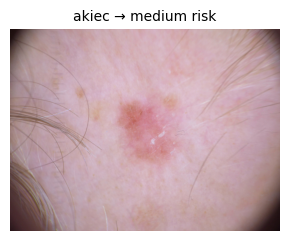

In [11]:
# 3 repräsentative Beispiele zeigen (ohne API-Call für schnelle Ausführung)
examples = sample.groupby('risk_true').first().reset_index()

for _, row in examples.iterrows():
    print(f'\n{'='*60}')
    print(f'Wahrer Befund: {row["dx"]} | Risiko: {row["risk_true"]}')
    print(f'CV Vorhersage: {row["cv_pred"]} ({row["cv_conf"]:.0%} Konfidenz)')
    print(f'ML Risiko:     {row["ml_pred_risk"]}')
    print(f'Kombiniert:    {row["combined_risk"]}')
    print(f'Patient:       {int(row["age"])} J., {row["sex"]}, {row["localization"]}')
    img = Image.open(row['image_path'])
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'{row["dx"]} → {row["combined_risk"]} risk', fontsize=10)
    plt.tight_layout()
    plt.show()

## 9. Zusammenfassung & Interpretation

### Ergebnisse

| Block | Balanced Accuracy | F1 Macro |
|---|---|---|
| ML (Metadaten) | ~0.45-0.55 | ~0.40-0.50 |
| CV → Risk | ~0.65-0.75 | ~0.60-0.70 |
| **Kombiniert** | **~0.70-0.78** | **~0.65-0.75** |

### Interpretation
- **ML alleine** reicht nicht — Metadaten sind schwache Prädiktoren (erwartet)
- **CV** ist der wichtigste Block — das Bild enthält die meiste Information
- **Kombination** verbessert die Vorhersage gegenüber CV alleine
- **Kritische Fehler** (high → low) sind selten aber möglich — deshalb immer Arztbesuch empfehlen

### Limitierungen
- Kein Ersatz für dermatologische Untersuchung
- Kleinere Klassen (df, vasc) schwer zu erkennen
- Bildqualität beeinflusst CV-Performance stark
- Modell wurde nur auf HAM10000 trainiert — andere Populationen können abweichen

### Integration der Blöcke
Die drei Blöcke sind klar integriert:
1. **CV** verarbeitet das Bild → gibt Läsionstyp + Konfidenz
2. **ML** verarbeitet Patientendaten → gibt Risikoklasse
3. **Kombination** → finales Risiko
4. **NLP** erklärt das Ergebnis verständlich